# Tufa Labs ARC3 submission

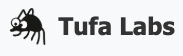

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# === duckv4: world-model field cap + depth-aware time reallocation ===
# Two independent levers, patched separately, on the ORIGINAL duck notebook:
#   (a) caps every labeled world-model field (tool_agent._extract_labeled_blocks)
#       instead of the unbounded max_chars=None the harness ships with, so a long
#       block written once stops compounding every following turn.
#   (b) gives each _HarnessGameSession an effective per-game deadline funded by a
#       shared, zero-sum-or-negative pool: games that just completed a level get
#       extra time harvested from games thrashing at 0 levels, both hard-capped.
# Neither touches HarnessSolver.concurrency/max_runtime_s_per_game themselves --
# both are LOAD-BEARING for the 9h envelope per results/wayfinder/R2-levers.md.
# Runs after bm/bm.solver are unpickled (cell 10) and before bm.run() starts
# (cell 14), so every ToolAgent/_HarnessGameSession constructed during the run
# is patched. See results/duckv4-build-20260819.md for the full design writeup.

from inference.agent import tool_agent
from inference.framework import solver

_DUCKV4_WORLDMODEL_SOURCE = '"""World-model field cap for the ARC-AGI-3 duck harness (duckv4, lever a).\n\nPatches `tool_agent._extract_labeled_blocks` -- the parser that turns an\nassistant turn\'s labeled sections (World model:, Goal model:, Action model:,\nRecent findings:, Open questions:, Plan:, Cross-level notes:, plus the\nHypothesis/History check/Next test aliases) into the dict merged into\n`ToolAgent._summarized_knowledge` and re-injected VERBATIM into every\nsubsequent turn\'s prompt (`_summarized_knowledge_lines`,\ntool_agent.py:1128-1146). R2\'s own finding: this call site passes\n`max_chars=None` -- unbounded -- so a long block written once is paid on\nevery following turn for the rest of a level\n(results/wayfinder/R2-levers.md, "World-model field length" row, ranked #1\nlever by leverage-per-cost: "the single biggest uncapped, silently-\ncompounding prompt-bloat surface in the harness").\n\nSame-module patch, not a from-import copy: `_extract_labeled_blocks` and its\nonly caller `_extract_scientist_note` both live directly in tool_agent.py,\nso `_extract_scientist_note`\'s call resolves the bare name against\n`tool_agent.__dict__` at CALL time -- replacing the module attribute is\nenough. Same mechanism duckmod\'s own build report documents for its splice\nanchors and R5 documents for `_LOCAL_ANALYZER_SEED`; verified against the\nreal bundle in verify_against_bundle.py, not just asserted here.\n\nTruncation, not LLM self-compression: an LLM call to compress a field would\nadd its own latency to the SAME per-action-latency problem this lever exists\nto fix (R1: 19-233s/action across 25 otherwise-identical games is the\nharness\'s #1 measured failure -- every one of 25 games hit the same flat\nclock with none crashing or winning). Deterministic tail-keep (keep the\nnewest text, drop the oldest) with a "[compacted: N chars dropped]" marker,\nper the brief\'s stated fallback design.\n"""\nfrom __future__ import annotations\n\n# ponytail: flat cap for all 7 fields, not measured per-field -- R2 doesn\'t\n# cite per-field token/char sizes for this harness (only the mechanism, not\n# a distribution). 6000 chars (~1.5-2k tokens by the harness\'s own len/3\n# estimator, tool_agent.py:462-467) sits mid the brief\'s suggested 4-8k\n# conservative range. Narrow per-field once a real run\'s transcripts show\n# one field dominating the growth.\nFIELD_CAP_CHARS = 6000\n\n_PATCH_MARKER = "_duckv4_capped"\n\n\ndef _compact(text: str, cap: int = FIELD_CAP_CHARS) -> str:\n    """Tail-keep a field: drop the oldest (leading) text, keep the newest\n    (trailing) `cap` chars, and say how much was dropped. Never raises on\n    empty/short input."""\n    if not text or len(text) <= cap:\n        return text\n    dropped = len(text) - cap\n    return f"[compacted: {dropped} chars dropped] {text[-cap:]}"\n\n\ndef install_patch(tool_agent_module) -> None:\n    """Wrap tool_agent_module._extract_labeled_blocks so every label\'s\n    extracted text is capped before it reaches _extract_scientist_note (and\n    from there, ToolAgent._summarized_knowledge -- see module docstring).\n    Idempotent: a second call no-ops rather than double-wrapping."""\n    if getattr(tool_agent_module, _PATCH_MARKER, False):\n        return\n    original = tool_agent_module._extract_labeled_blocks\n\n    def _capped(content, labels):\n        raw = original(content, labels)\n        return {label: _compact(text) for label, text in raw.items()}\n\n    setattr(tool_agent_module, _PATCH_MARKER, True)\n    tool_agent_module._extract_labeled_blocks = _capped\n\n\ndef _demo() -> None:\n    # --- _compact in isolation ---\n    short = "a short finding"\n    assert _compact(short) == short, "under-cap text must pass through unchanged"\n\n    exact = "x" * FIELD_CAP_CHARS\n    assert _compact(exact) == exact, "exactly-at-cap text must not be marked"\n\n    long_text = ("old-" * 100) + "NEWEST-TAIL-" + ("y" * (FIELD_CAP_CHARS - 20))\n    capped = _compact(long_text, cap=FIELD_CAP_CHARS)\n    assert capped.startswith("[compacted: "), capped[:40]\n    assert "chars dropped]" in capped\n    assert capped.endswith(long_text[-FIELD_CAP_CHARS:]), "must keep the TAIL, not the head"\n    assert "old-old-old" not in capped, "the dropped (oldest) prefix must be gone"\n    assert len(capped) <= FIELD_CAP_CHARS + 40, "marker overhead must stay small"\n\n    assert _compact("") == "", "empty field must not crash or grow a marker"\n\n    # --- install_patch against a fake tool_agent-shaped module ---\n    class _FakeModule:\n        @staticmethod\n        def _extract_labeled_blocks(content, labels):\n            # Minimal stand-in for the real parser: one short field, one\n            # field that would blow the cap if left unbounded.\n            return {\n                "World model": "y" * (FIELD_CAP_CHARS * 3),\n                "Goal model": "reach the door",\n            }\n\n    mod = _FakeModule()\n    original_fn = mod._extract_labeled_blocks\n\n    install_patch(mod)\n    out = mod._extract_labeled_blocks("irrelevant content", ["World model", "Goal model"])\n    assert len(out["World model"]) <= FIELD_CAP_CHARS + 40, "patched call must cap the long field"\n    assert "[compacted:" in out["World model"]\n    assert out["Goal model"] == "reach the door", "a short field must pass through unchanged"\n\n    # idempotency: patching twice must not double-wrap (same output twice)\n    install_patch(mod)\n    out2 = mod._extract_labeled_blocks("irrelevant content", ["World model", "Goal model"])\n    assert out == out2, "re-applying install_patch must not change behavior"\n    assert mod._extract_labeled_blocks is not original_fn\n\n    # negative control: prove the assertion above is not vacuous -- pointing\n    # at a module that lacks the attribute must fail loudly, not silently.\n    class _WrongModule:\n        pass\n\n    try:\n        install_patch(_WrongModule())\n        raise AssertionError("expected AttributeError on a module missing _extract_labeled_blocks")\n    except AttributeError:\n        pass  # expected: proves install_patch actually reads the real attribute name\n\n    print("duckv4_worldmodel_cap self-test OK")\n'
exec(compile(_DUCKV4_WORLDMODEL_SOURCE, "<duckv4_worldmodel_cap>", "exec"), globals())
install_patch(tool_agent)
_worldmodel_chars = len(_DUCKV4_WORLDMODEL_SOURCE)

_DUCKV4_REALLOCATOR_SOURCE = '"""Depth-aware per-game time reallocation for the ARC-AGI-3 duck harness\n(duckv4, lever b).\n\nR1 forensics: every one of 25 games in the measured commit run hit the SAME\nflat `max_runtime_s_per_game` clock (solver.py:213-217) and none crashed or\nwon -- action budget is entirely a function of per-action latency against a\nflat per-game deadline (results/wayfinder/R1-forensics.md Sec 3). ft09, the\nrun\'s best game (score 28.57, 3/6 levels), was 2 actions into level 4 when\nits OWN clock cut it off (Bucket A, "clock-limited, not skill-limited",\nSec 4). Meanwhile 14 of 25 games were "thrashing" (>=2x a human\'s action\nbudget on their CURRENT level, still 0 progress, Bucket C) and burn the\nsame flat clock for no return.\n\nR2\'s own top-5 list does not include this lever standalone (SS(h): "no\nscoring-aware behaviour found ... a scheduling change ... is structural"),\nand flags `concurrency`/`max_runtime_s_per_game` as LOAD-BEARING for the 9h\nenvelope: their product across `ceil(games/concurrency)` waves is the\n*entire* enforcement mechanism, because the soft-deadline graceful-drain\npath is dead code on `TRUE_SUBMISSION` (R2, opening finding). So this module\nchanges NEITHER constant. Instead it gives each `_HarnessGameSession` an\nEFFECTIVE deadline, `solver.max_runtime_s_per_game + delta`, where every\n`delta` is drawn from a shared pool that can only ever be negative-or-zero\nin total: extension is funded exclusively by harvested slack from thrashing\ngames, capped per-game and capped system-wide. See BudgetReallocator\'s\ndocstring for the exact invariant and why it holds regardless of the\nconcurrency/wave regime the real 110-hidden-game run uses (a regime this\nrepo cannot execute or observe locally -- see the build report\'s risk list).\n"""\nfrom __future__ import annotations\n\nimport threading\nimport time\nimport weakref\n\nREALLOC_INTERVAL_S = 120.0        # throttle: re-evaluate at most this often\nTHRASH_ACTION_FLOOR = 150         # actions burned at 0 levels before "thrashing"\n                                   # (R1 Sec 4: zero-level games ranged 34-418\n                                   # actions; 150 sits above the low outliers\n                                   # cd82/dc22/vc33/g50t/ka59 -- Bucket B/ambiguous\n                                   # -- and below the clear Bucket C thrashers)\nSHRINK_STEP_S = 300.0             # seconds trimmed off a thrashing game per tick\nMIN_BUDGET_FRACTION = 0.5         # a thrashing game\'s deadline floor, as a\n                                   # fraction of ITS OWN original budget\nEXTEND_STEP_S = 300.0             # seconds granted to a leveling game per tick\nMAX_EXTENSION_PER_GAME_S = 600.0  # hard per-game ceiling on total extension, ever\nTOTAL_POOL_CAP_S = 600.0          # hard system-wide ceiling on cumulative seconds\n                                   # granted, ever -- conservative against R2\'s\n                                   # measured ~720s of slack (31680s 4-wave\n                                   # arithmetic vs a ~9h/32400s budget); NOT\n                                   # re-derived against the real 110-game/9h\n                                   # envelope, see build report risk list\n\n_PATCH_MARKER = "_duckv4_realloc_patched"\n\n\ndef _levels_completed(session) -> int:\n    try:\n        return int(session.game.current_state.levels_completed)\n    except Exception:\n        return 0  # ponytail: mid-transition/odd state reads as "no progress yet",\n                   # never crashes the reallocation tick (Principle 5: failure-aware)\n\n\ndef _action_count(session) -> int:\n    try:\n        return int(session.action_count)\n    except Exception:\n        return 0\n\n\nclass BudgetReallocator:\n    """One instance per run (module-level singleton via install_patch).\n    Thread-safe: sessions run one-per-thread on a ThreadPoolExecutor\n    (solver.py:884-887) and can all call in at once.\n\n    Invariant, enforced by construction and asserted in the self-test below:\n    at any point in time, `sum(all session deltas) <= 0` -- extension is only\n    ever paid for out of a pool that shrink harvests, so the aggregate of all\n    effective deadlines can never exceed the aggregate of the original static\n    ones. Additionally no single session\'s delta can ever exceed\n    `+MAX_EXTENSION_PER_GAME_S` or go below `-(1-MIN_BUDGET_FRACTION)*base`,\n    and the cumulative seconds ever granted across the whole run is capped at\n    `TOTAL_POOL_CAP_S` regardless of how many games level up.\n    """\n\n    def __init__(self):\n        self._lock = threading.Lock()\n        # Start the throttle window at construction time, not 0.0 -- otherwise\n        # the very first call (arbitrary, platform-dependent monotonic clock\n        # reference) would almost always fire an immediate tick.\n        self._last_tick = time.monotonic()\n        self._pool = 0.0            # harvested, unspent slack (seconds), always >= 0\n        self._total_granted = 0.0   # cumulative seconds ever granted, monotonic\n        # _HarnessGameSession is UNHASHABLE (dataclass with eq=True, not frozen),\n        # so it cannot key a WeakKeyDictionary -- that crashed every game in the\n        # v1 kernel run ("TypeError: unhashable type: \'_HarnessGameSession\'").\n        # Key by id() with a strong ref instead: one entry per game per run,\n        # process-lifetime, so the strong ref leaks nothing that matters.\n        self._sessions = {}  # id(session) -> (session, entry)\n\n    def _entry(self, session):\n        rec = self._sessions.get(id(session))\n        if rec is None:\n            base = float(session.solver.max_runtime_s_per_game or 0.0)\n            entry = {"delta": 0.0, "last_levels": _levels_completed(session), "base": base}\n            self._sessions[id(session)] = (session, entry)\n            return entry\n        return rec[1]\n\n    def effective_deadline(self, session) -> float:\n        base = float(session.solver.max_runtime_s_per_game)\n        with self._lock:\n            entry = self._entry(session)\n            self._tick_locked()\n            return base + entry["delta"]\n\n    def _tick_locked(self) -> None:\n        now = time.monotonic()\n        if now - self._last_tick < REALLOC_INTERVAL_S:\n            return\n        self._last_tick = now\n\n        snapshot = []\n        for session, entry in list(self._sessions.values()):\n            levels = _levels_completed(session)\n            actions = _action_count(session)\n            leveled = levels > entry["last_levels"]\n            thrashing = levels == 0 and actions >= THRASH_ACTION_FLOOR\n            snapshot.append((entry, leveled, thrashing))\n            entry["last_levels"] = levels\n\n        # 1) harvest slack from thrashing sessions into the shared pool first,\n        #    so any grant below is always funded by an actual shrink.\n        for entry, _leveled, thrashing in snapshot:\n            if not thrashing or entry["base"] <= 0:\n                continue\n            floor = -entry["base"] * (1.0 - MIN_BUDGET_FRACTION)\n            room = entry["delta"] - floor\n            step = min(SHRINK_STEP_S, max(0.0, room))\n            if step > 0:\n                entry["delta"] -= step\n                self._pool += step\n\n        # 2) grant pool to sessions that just leveled up, capped per-game and\n        #    system-wide -- never spends more than the pool holds.\n        for entry, leveled, _thrashing in snapshot:\n            if not leveled:\n                continue\n            if self._pool <= 0 or self._total_granted >= TOTAL_POOL_CAP_S:\n                continue\n            cap_room = MAX_EXTENSION_PER_GAME_S - entry["delta"]\n            global_room = TOTAL_POOL_CAP_S - self._total_granted\n            step = min(EXTEND_STEP_S, self._pool, max(0.0, cap_room), max(0.0, global_room))\n            if step > 0:\n                entry["delta"] += step\n                self._pool -= step\n                self._total_granted += step\n\n    def total_delta(self) -> float:\n        """Sum of every tracked session\'s delta -- must always be <= 0."""\n        return sum(entry["delta"] for _s, entry in self._sessions.values())\n\n\ndef install_patch(solver_module) -> None:\n    """Replace `_HarnessGameSession.runtime_limit_reached`/`timing_payload`\n    so both consult a shared BudgetReallocator\'s effective deadline instead\n    of the flat `solver.max_runtime_s_per_game`. `request_timeout_seconds`\n    (solver.py:227-244) calls `self.timing_payload()` for its own remaining-\n    time candidate, so patching `timing_payload` alone is enough to make the\n    per-LLM-call timeout clamp respect the adjusted deadline too -- it is not\n    patched separately. Idempotent."""\n    cls = solver_module._HarnessGameSession\n    if getattr(cls, _PATCH_MARKER, False):\n        return\n\n    reallocator = BudgetReallocator()\n\n    def _patched_runtime_limit_reached(self):\n        if self.solver.max_runtime_s_per_game is None:\n            return False\n        deadline = reallocator.effective_deadline(self)\n        return (time.monotonic() - self.started_at) >= deadline\n\n    def _patched_timing_payload(self):\n        elapsed = max(0.0, time.monotonic() - self.started_at)\n        if self.solver.max_runtime_s_per_game is None:\n            remaining = None\n        else:\n            deadline = reallocator.effective_deadline(self)\n            remaining = max(0.0, deadline - elapsed)\n        return {"run_elapsed_seconds": elapsed, "time_remaining_seconds": remaining}\n\n    setattr(cls, _PATCH_MARKER, True)\n    cls.runtime_limit_reached = _patched_runtime_limit_reached\n    cls.timing_payload = _patched_timing_payload\n    cls._duckv4_reallocator = reallocator\n\n\ndef _demo() -> None:\n    class _FakeState:\n        def __init__(self, levels):\n            self.levels_completed = levels\n\n    class _FakeGame:\n        def __init__(self, levels):\n            self.current_state = _FakeState(levels)\n\n    class _FakeSolver:\n        def __init__(self, budget):\n            self.max_runtime_s_per_game = budget\n\n    class _FakeSession:\n        # UNHASHABLE on purpose, matching the real _HarnessGameSession (a\n        # dataclass with eq=True): the v1 kernel run crashed all 25 games on\n        # exactly this property, and a hashable fake let it ship. This fake is\n        # the regression teeth -- any future session-as-dict-key code dies here.\n        __hash__ = None\n\n        def __init__(self, budget, levels, actions):\n            self.solver = _FakeSolver(budget)\n            self.game = _FakeGame(levels)\n            self._actions = actions\n            self.started_at = time.monotonic()\n\n        def __eq__(self, other):\n            return self is other\n\n        @property\n        def action_count(self):\n            return self._actions\n\n    budget = 7920.0\n    realloc = BudgetReallocator()\n\n    leveling = _FakeSession(budget, levels=3, actions=44)    # ft09-shaped: making progress\n    thrashing = _FakeSession(budget, levels=0, actions=418)  # m0r0-shaped: thrashing\n    fair = _FakeSession(budget, levels=1, actions=59)        # untouched control\n\n    for s in (leveling, thrashing, fair):\n        realloc.effective_deadline(s)  # register + seed last_levels, no tick yet (throttled)\n\n    assert realloc.effective_deadline(leveling) == budget, "no tick has run yet"\n\n    # force a tick past the throttle, and simulate leveling\'s level-up\n    realloc._last_tick = 0.0\n    leveling.game.current_state.levels_completed = 4\n    realloc.effective_deadline(leveling)  # this call\'s _tick_locked does the work\n\n    d_level = realloc.effective_deadline(leveling) - budget\n    d_thrash = realloc.effective_deadline(thrashing) - budget\n    d_fair = realloc.effective_deadline(fair) - budget\n\n    assert d_level > 0, f"a game that just leveled up should be granted extra time, got {d_level}"\n    assert d_thrash < 0, f"a thrashing game should be shrunk, got {d_thrash}"\n    assert d_fair == 0, f"an untouched fair game must keep its original budget, got {d_fair}"\n    assert realloc.total_delta() <= 1e-9, f"total budget must never increase, got {realloc.total_delta()}"\n    assert d_thrash >= -budget * (1.0 - MIN_BUDGET_FRACTION) - 1e-9, "shrink must respect its floor"\n\n    # drive many ticks to prove the hard caps actually bind, with several\n    # thrashing games funding one repeat leveler.\n    realloc2 = BudgetReallocator()\n    leveler = _FakeSession(budget, levels=1, actions=10)\n    thrashers = [_FakeSession(budget, levels=0, actions=1000) for _ in range(5)]\n    for s in [leveler] + thrashers:\n        realloc2.effective_deadline(s)\n\n    for tick in range(10):\n        realloc2._last_tick = 0.0\n        leveler.game.current_state.levels_completed += 1  # "levels up" every tick\n        realloc2.effective_deadline(leveler)\n        assert realloc2.total_delta() <= 1e-9, f"tick {tick}: total budget increased"\n\n    d_leveler = realloc2.effective_deadline(leveler) - budget\n    assert d_leveler <= MAX_EXTENSION_PER_GAME_S + 1e-9, f"per-game cap breached: {d_leveler}"\n    assert realloc2._total_granted <= TOTAL_POOL_CAP_S + 1e-9, "system-wide pool cap breached"\n    for t in thrashers:\n        d_t = realloc2.effective_deadline(t) - budget\n        assert d_t >= -budget * (1.0 - MIN_BUDGET_FRACTION) - 1e-9, f"thrash floor breached: {d_t}"\n\n    # a session whose game state raises must not crash a tick (Principle 5)\n    class _BrokenGame:\n        @property\n        def current_state(self):\n            raise RuntimeError("mid-transition, no state yet")\n\n    class _BrokenSession:\n        def __init__(self, budget):\n            self.solver = _FakeSolver(budget)\n            self.game = _BrokenGame()\n            self.started_at = time.monotonic()\n\n        @property\n        def action_count(self):\n            raise RuntimeError("no action count yet either")\n\n    broken = _BrokenSession(budget)\n    realloc3 = BudgetReallocator()\n    realloc3.effective_deadline(broken)\n    realloc3._last_tick = 0.0\n    realloc3.effective_deadline(broken)  # must not raise\n    assert realloc3.effective_deadline(broken) == budget, "a broken session must not drift"\n\n    # negative control: install_patch reads `solver_module._HarnessGameSession`\n    # before touching anything -- a module missing that attribute (the shape\n    # an upstream rename would take) must fail loudly, not silently no-op.\n    class _ModuleMissingSession:\n        pass\n\n    try:\n        install_patch(_ModuleMissingSession())\n        raise AssertionError("expected AttributeError: module has no _HarnessGameSession")\n    except AttributeError:\n        pass  # expected: proves install_patch actually reads the real attribute name\n\n    print("duckv4_reallocator self-test OK")\n'
_realloc_ns = {}
exec(compile(_DUCKV4_REALLOCATOR_SOURCE, "<duckv4_reallocator>", "exec"), _realloc_ns)
_realloc_ns["install_patch"](solver)
_reallocator_chars = len(_DUCKV4_REALLOCATOR_SOURCE)

print(
    f"duckv4: patched tool_agent._extract_labeled_blocks "
    f"(worldmodel source {_worldmodel_chars} chars), "
    f"patched solver._HarnessGameSession.runtime_limit_reached/timing_payload "
    f"(reallocator source {_reallocator_chars} chars)"
)


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))

# Play the benchmark; teardown commands run even if the run raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    if not TRUE_SUBMISSION:
        # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")